# 文本预处理

## 1. 读取数据集

In [2]:
import collections
import re
import torch

In [3]:
def read_time_machine():
    ''' 加载时间机器数据集 '''
    with open('time_machine.txt', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()
print(len(lines))
print(lines[0])
print(lines[10])


3558
the project gutenberg ebook of the time machine
title the time machine


## 2. 词元化

In [4]:
def tokenize(lines, token='word'):
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('错误：未知token类型' + token)

tokens = tokenize(lines)
for i in range(11):
    print(tokens[i])

['the', 'project', 'gutenberg', 'ebook', 'of', 'the', 'time', 'machine']
[]
['this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and']
['most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions']
['whatsoever', 'you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 're', 'use', 'it', 'under', 'the', 'terms']
['of', 'the', 'project', 'gutenberg', 'license', 'included', 'with', 'this', 'ebook', 'or', 'online']
['at', 'www', 'gutenberg', 'org', 'if', 'you', 'are', 'not', 'located', 'in', 'the', 'united', 'states']
['you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located']
['before', 'using', 'this', 'ebook']
[]
['title', 'the', 'time', 'machine']


## 3. 词表

In [5]:
class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.idx_to_token:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[idx] for idx in indices]

    @property 
    def unk(self):
        return 0
    
    @property 
    def token_freqs(self):
        return self._token_freqs
    

def count_corpus(tokens):
    if len(tokens) == 0 or isinstance(tokens[0], list):
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)


In [6]:
vocab = Vocab(tokens)
print(list(vocab.token_to_idx.items())[:10])

[('<unk>', 0), ('the', 1), ('and', 2), ('of', 3), ('i', 4), ('a', 5), ('to', 6), ('in', 7), ('was', 8), ('that', 9)]


In [7]:
for i in [0, 10]:
    print('文本：', tokens[i])
    print('索引：', vocab[tokens[i]])

文本： ['the', 'project', 'gutenberg', 'ebook', 'of', 'the', 'time', 'machine']
索引： [1, 53, 44, 313, 3, 1, 19, 46]
文本： ['title', 'the', 'time', 'machine']
索引： [2442, 1, 19, 46]


# 4. 整合

In [8]:
def load_corpus_time_machine(max_tokens=-1):
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

corpus, vocab = load_corpus_time_machine()
len(corpus), len(vocab)


(189388, 28)

In [29]:
corpus[:10]

[3, 10, 2, 1, 20, 9, 6, 25, 2, 15]

# 语言模型和数据集

## 1. 自然语言统计

In [10]:
import random
import torch
import matplotlib.pyplot as plt


In [11]:
tokens = tokenize(read_time_machine())
corpus = [token for line in tokens for token in line]
vocab = Vocab(corpus)
vocab.token_freqs[:10]

[('the', 2477),
 ('and', 1312),
 ('of', 1285),
 ('i', 1268),
 ('a', 877),
 ('to', 766),
 ('in', 605),
 ('was', 554),
 ('that', 458),
 ('it', 452)]

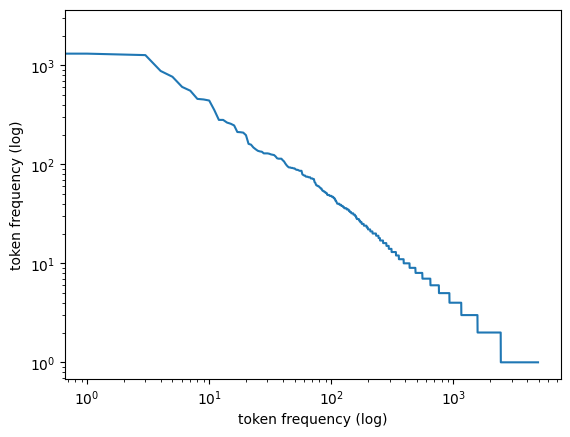

In [15]:
freqs = [freq for token, freq in vocab.token_freqs]
plt.plot(freqs)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('token frequency (log)')
plt.ylabel('token frequency (log)')
plt.show()

In [16]:
bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]


[(('of', 'the'), 344),
 (('in', 'the'), 192),
 (('i', 'had'), 130),
 (('and', 'the'), 112),
 (('i', 'was'), 112),
 (('the', 'time'), 110),
 (('to', 'the'), 101),
 (('it', 'was'), 99),
 (('project', 'gutenberg'), 88),
 (('as', 'i'), 78)]

In [17]:
triple_tokens = [pair for pair in zip(corpus[:-2], corpus[1:-1], corpus[2:])]
triple_vocab = Vocab(triple_tokens)
triple_vocab.token_freqs[:10]


[(('the', 'time', 'traveller'), 63),
 (('the', 'time', 'machine'), 34),
 (('the', 'project', 'gutenberg'), 33),
 (('the', 'medical', 'man'), 24),
 (('project', 'gutenberg', 'electronic'), 18),
 (('it', 'seemed', 'to'), 16),
 (('it', 'was', 'a'), 15),
 (('here', 'and', 'there'), 15),
 (('the', 'united', 'states'), 14),
 (('seemed', 'to', 'me'), 14)]

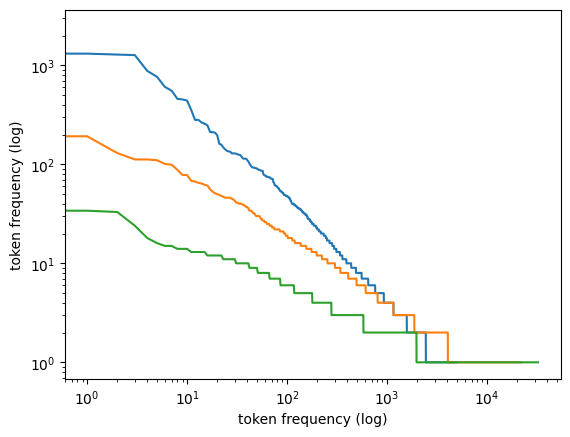

In [18]:
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
triple_freqs = [freq for token, freq in triple_vocab.token_freqs]

plt.plot(freqs)
plt.plot(bigram_freqs)
plt.plot(triple_freqs)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('token frequency (log)')
plt.ylabel('token frequency (log)')
plt.show()


## 2. 随机抽样

In [19]:
def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos:pos + num_steps]
    
    num_batches = num_subseqs // batch_size

    for i in range(0, batch_size * num_batches, batch_size):
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

In [20]:
my_seq = list(range(35))
for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY: ', Y)

X:  tensor([[29, 30, 31, 32, 33],
        [19, 20, 21, 22, 23]]) 
Y:  tensor([[30, 31, 32, 33, 34],
        [20, 21, 22, 23, 24]])
X:  tensor([[24, 25, 26, 27, 28],
        [14, 15, 16, 17, 18]]) 
Y:  tensor([[25, 26, 27, 28, 29],
        [15, 16, 17, 18, 19]])
X:  tensor([[ 4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13]]) 
Y:  tensor([[ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]])


## 3. 顺序分区

In [21]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - 1 - offset) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + num_tokens + 1])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_batches * num_steps, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [22]:
for X, Y in seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY: ', Y)

X:  tensor([[ 4,  5,  6,  7,  8],
        [19, 20, 21, 22, 23]]) 
Y:  tensor([[ 5,  6,  7,  8,  9],
        [20, 21, 22, 23, 24]])
X:  tensor([[ 9, 10, 11, 12, 13],
        [24, 25, 26, 27, 28]]) 
Y:  tensor([[10, 11, 12, 13, 14],
        [25, 26, 27, 28, 29]])
X:  tensor([[14, 15, 16, 17, 18],
        [29, 30, 31, 32, 33]]) 
Y:  tensor([[15, 16, 17, 18, 19],
        [30, 31, 32, 33, 34]])


In [ ]:
class SeqDataLoader:
    """序列数据加载器"""

    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = seq_data_iter_random
        else:
            self.data_iter_fn = seq_data_iter_sequential
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps
    
    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)


In [25]:
def load_data_time_machine(batch_size, num_steps, use_random_iter=False, max_tokens=10000):
    data_iter = SeqDataLoader(batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab